## 1. L1 Regularization (Lasso)
* Definition: Adds a penalty proportional to the absolute values of the model weights ($\sum \vert{}w_i\vert{}$) to the loss function.
* Use Cases: Feature selection, sparse modeling, and linear regression models handling high-dimensional data.
* Pros:
    * Drives irrelevant feature weights completely to zero (automatic feature selection).
    * Creates sparse, interpretable models.
* Cons:
    * Can be unstable when features are highly correlated (arbitrarily picks one and ignores others).
    * Non-differentiable at zero, which can complicate certain optimization routes.

### Visualizing L1 Regularization (Lasso) on Polynomial Curve Fitting
In this example, we apply L1 Regularization (Lasso) to a high-complexity Degree 15 polynomial model to see how it controls extreme fluctuations and fits the underlying true function.

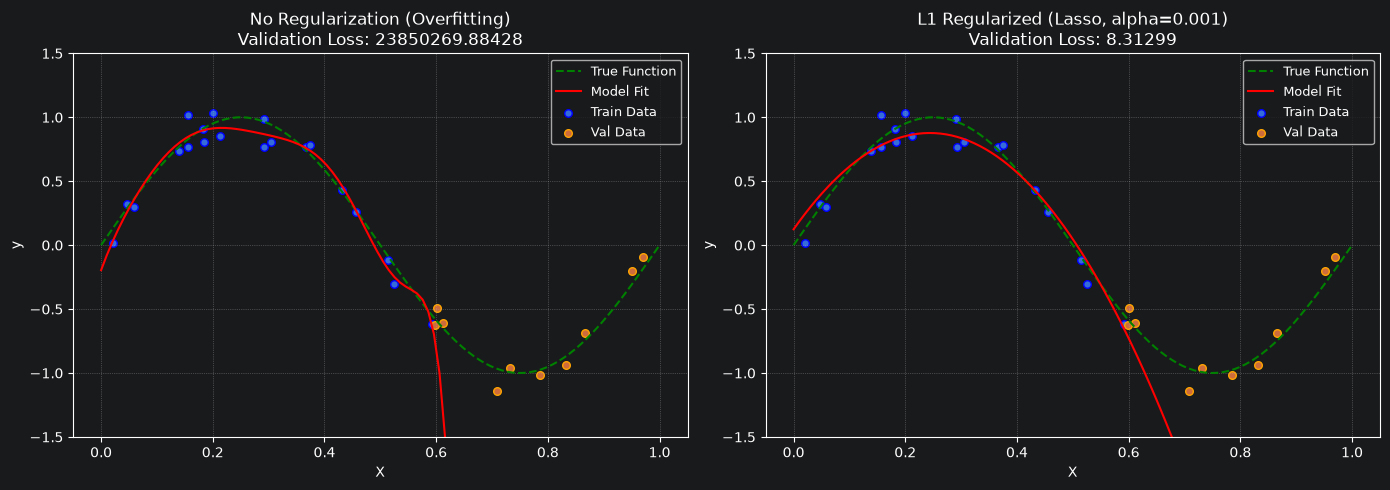

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error

# 1. Generate synthetic dataset with noise
np.random.seed(42)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.sin(2 * np.pi * X) + np.random.randn(n_samples) * 0.1

# Split into train and validation sets
X_train, X_val = X[:20], X[20:]
y_train, y_val = y[:20], y[20:]

# 2. Define Models: No Regularization vs L1 Regularized (Lasso)
models = {
    "No Regularization (Overfitting)": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("regressor", LinearRegression())
    ]),
    "L1 Regularized (Lasso, alpha=0.001)": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("regressor", Lasso(alpha=0.001, max_iter=10000))
    ])
}

# 3. Plotting side-by-side comparison
plt.figure(figsize=(14, 5))
X_test = np.linspace(0, 1, 100)

for i, (name, pipeline) in enumerate(models.items()):
    ax = plt.subplot(1, 2, i + 1)

    # Train the model
    pipeline.fit(X_train[:, np.newaxis], y_train)

    # Evaluate validation error
    val_loss = mean_squared_error(y_val, pipeline.predict(X_val[:, np.newaxis]))

    # Plotting
    plt.plot(X_test, np.sin(2 * np.pi * X_test), label="True Function", color="green", linestyle="--")
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model Fit", color="red")
    plt.scatter(X_train, y_train, edgecolor="b", s=30, label="Train Data")
    plt.scatter(X_val, y_val, edgecolor="orange", s=30, label="Val Data")

    plt.title(f"{name}\nValidation Loss: {val_loss:.5f}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend(loc="best", fontsize=9)
    plt.ylim(-1.5, 1.5)
    plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 2. L2 Regularization (Ridge)
* Definition: Adds a penalty proportional to the squared values of the model weights ($\sum w_i^2$) to the loss function.
* Use Cases: Preventing multicollinearity in regression and controlling weight magnitudes in neural networks.
* Pros:
    * Smoothly shrinks weights toward zero without eliminating them entirely.
    * Handles correlated features gracefully and reduces model variance effectively.
* Cons:
    * Does not perform feature selection (all features are retained with smaller weights).
    * May underperform if only a sparse subset of features is truly relevant.

### Visualizing L2 Regularization (Ridge)
Here we take a high-complexity model (Degree 15 Polynomial) and observe how L2 Regularization penalizes large weights to smooth out the curve and prevent overfitting.

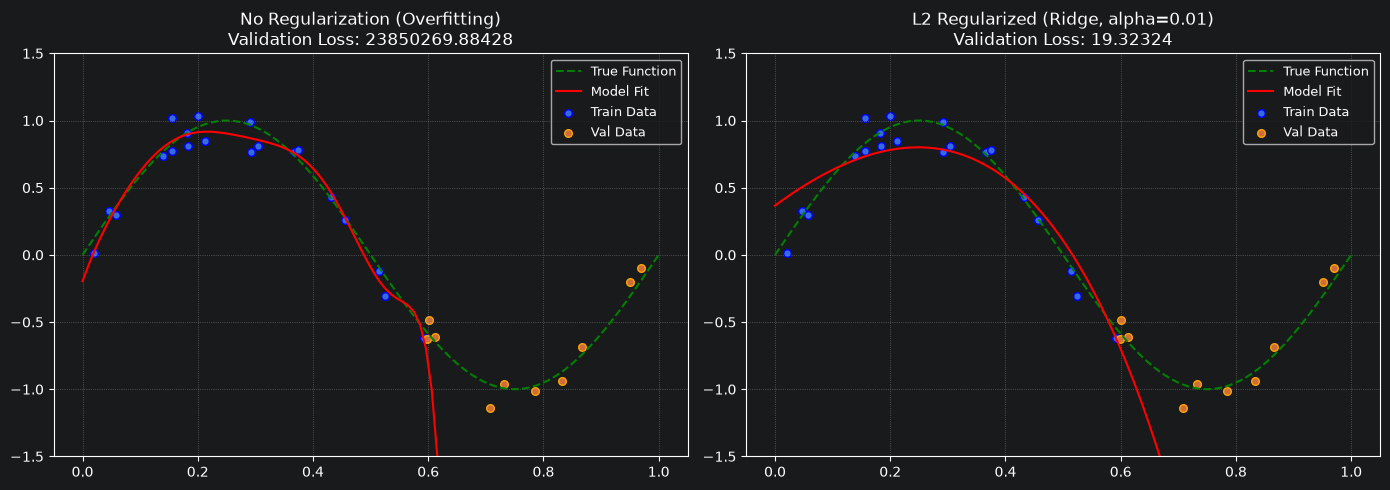

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

# 1. Generate synthetic dataset with noise
np.random.seed(42)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.sin(2 * np.pi * X) + np.random.randn(n_samples) * 0.1

# Split into train and validation sets
X_train, X_val = X[:20], X[20:]
y_train, y_val = y[:20], y[20:]

# 2. Define models to compare: Unregularized vs L2 Regularized (Degree 15)
models = {
    "No Regularization (Overfitting)": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("regressor", LinearRegression())
    ]),
    "L2 Regularized (Ridge, alpha=0.01)": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("regressor", Ridge(alpha=0.01))
    ])
}

# 3. Plotting comparison
plt.figure(figsize=(14, 5))
X_test = np.linspace(0, 1, 100)

for i, (name, pipeline) in enumerate(models.items()):
    ax = plt.subplot(1, 2, i + 1)

    # Train the model
    pipeline.fit(X_train[:, np.newaxis], y_train)

    # Evaluate validation error
    val_loss = mean_squared_error(y_val, pipeline.predict(X_val[:, np.newaxis]))

    # Plotting
    plt.plot(X_test, np.sin(2 * np.pi * X_test), label="True Function", color="green", linestyle="--")
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model Fit", color="red")
    plt.scatter(X_train, y_train, edgecolor="b", s=30, label="Train Data")
    plt.scatter(X_val, y_val, edgecolor="orange", s=30, label="Val Data")

    plt.title(f"{name}\nValidation Loss: {val_loss:.5f}")
    plt.legend(loc="best", fontsize=9)
    plt.ylim(-1.5, 1.5)
    plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

### Comparing L1 (Lasso) and L2 (Ridge) Regularization
In this section, we compare an unregularized high-complexity model (Degree 15) against **L1 Regularization (Lasso)** and **L2 Regularization (Ridge)**. Both techniques penalize large model weights to prevent overfitting, keeping the fitted curve smooth and close to the true function.

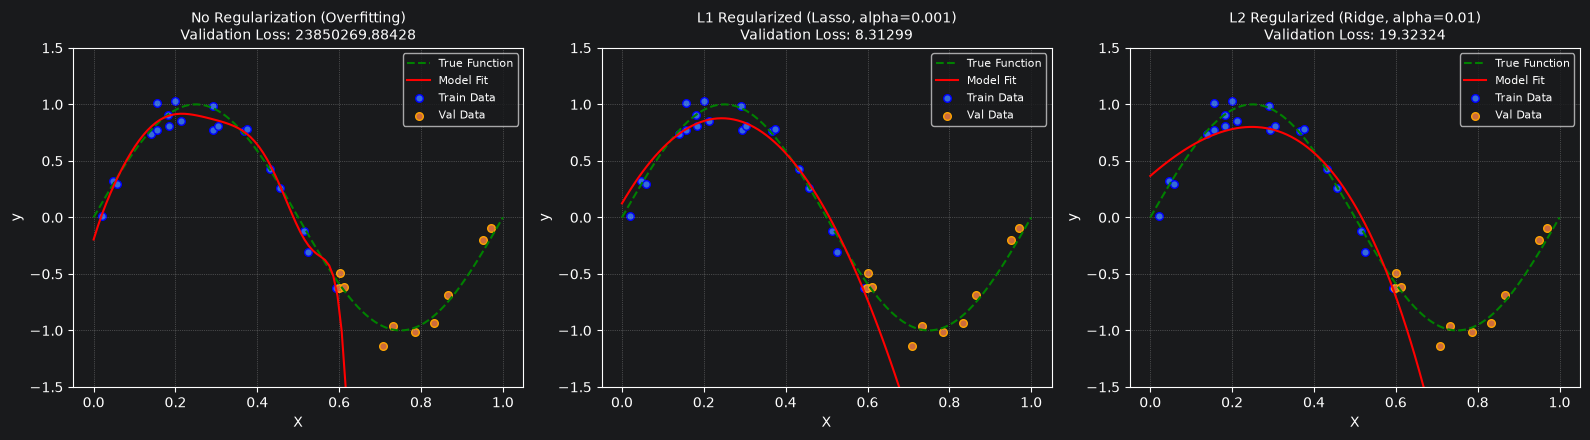

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error

# 1. Generate synthetic dataset with noise
np.random.seed(42)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.sin(2 * np.pi * X) + np.random.randn(n_samples) * 0.1

# Split into train and validation sets
X_train, X_val = X[:20], X[20:]
y_train, y_val = y[:20], y[20:]

# 2. Define models to compare: No Regularization vs L1 (Lasso) vs L2 (Ridge)
models = {
    "No Regularization (Overfitting)": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("regressor", LinearRegression())
    ]),
    "L1 Regularized (Lasso, alpha=0.001)": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("regressor", Lasso(alpha=0.001, max_iter=10000))
    ]),
    "L2 Regularized (Ridge, alpha=0.01)": Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("regressor", Ridge(alpha=0.01))
    ])
}

# 3. Plotting side-by-side comparison
plt.figure(figsize=(16, 4.5))
X_test = np.linspace(0, 1, 100)

for i, (name, pipeline) in enumerate(models.items()):
    ax = plt.subplot(1, 3, i + 1)

    # Train the model
    pipeline.fit(X_train[:, np.newaxis], y_train)

    # Evaluate validation error
    val_loss = mean_squared_error(y_val, pipeline.predict(X_val[:, np.newaxis]))

    # Plotting
    plt.plot(X_test, np.sin(2 * np.pi * X_test), label="True Function", color="green", linestyle="--")
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model Fit", color="red")
    plt.scatter(X_train, y_train, edgecolor="b", s=30, label="Train Data")
    plt.scatter(X_val, y_val, edgecolor="orange", s=30, label="Val Data")

    plt.title(f"{name}\nValidation Loss: {val_loss:.5f}", fontsize=10)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend(loc="best", fontsize=8)
    plt.ylim(-1.5, 1.5)
    plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 3. Weight Decay
* Definition: An optimization-level regularization technique that directly shrinks weights during gradient descent updates (mathematically equivalent to L2 regularization).
* Use Cases: Training deep neural networks using optimizers like SGD or AdamW.
* Pros:
    * Efficiently integrated directly into parameter update steps.
    * Prevents weights from growing excessively large and stabilizes training dynamics.
* Cons:
    * Requires careful tuning of the decay hyperparameter; improper tuning can slow convergence or cause underfitting.

### Visualizing Weight Decay
Here we simulate how weight decay penalizes and shrinks the magnitude of model weights over training steps, preventing them from blowing up.

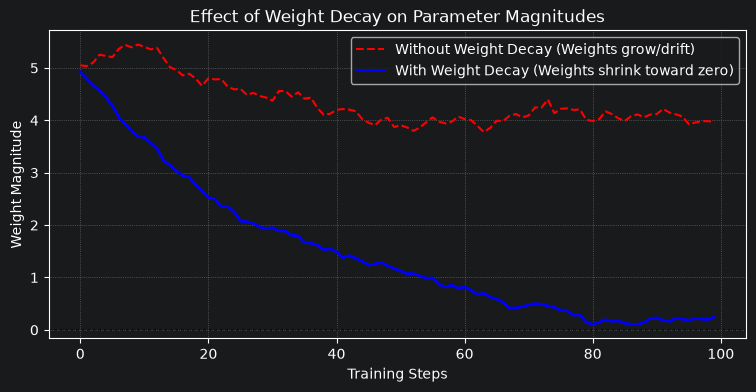

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate weight magnitude over training steps with and without weight decay
steps = 100
np.random.seed(42)

weights_no_decay = np.cumsum(np.random.randn(steps) * 0.1) + 5.0
weights_with_decay = []
w = 5.0
decay_rate = 0.03

for _ in range(steps):
    w = w - 0.05 * np.random.randn() - decay_rate * w  # Gradient step + weight decay
    weights_with_decay.append(w)

plt.figure(figsize=(9, 4))
plt.plot(weights_no_decay, label="Without Weight Decay (Weights grow/drift)", color="red", linestyle="--")
plt.plot(weights_with_decay, label="With Weight Decay (Weights shrink toward zero)", color="blue", linewidth=2)
plt.axhline(0, color="black", linestyle=":", alpha=0.5)

plt.xlabel("Training Steps")
plt.ylabel("Weight Magnitude")
plt.title("Effect of Weight Decay on Parameter Magnitudes")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

## 4. Dropout
* Definition: A regularization method where a random subset of neurons is temporarily deactivated ("dropped out") with probability $p$ at each training step.
* Use Cases: Fully connected and convolutional layers in deep neural networks.
* Pros:
    * Prevents co-adaptation of feature detectors, forcing the network to learn robust, redundant pathways.
    * Highly effective at reducing overfitting in deep architectures.
* Cons:
    * Increases training time per epoch.
    * Must be turned off during evaluation/inference, requiring proper scaling compensation.

### Visualizing Dropout Activation Mask
This visualization demonstrates how dropout randomly zeroes out a fraction of neuron activations during training while scaling the survivors.

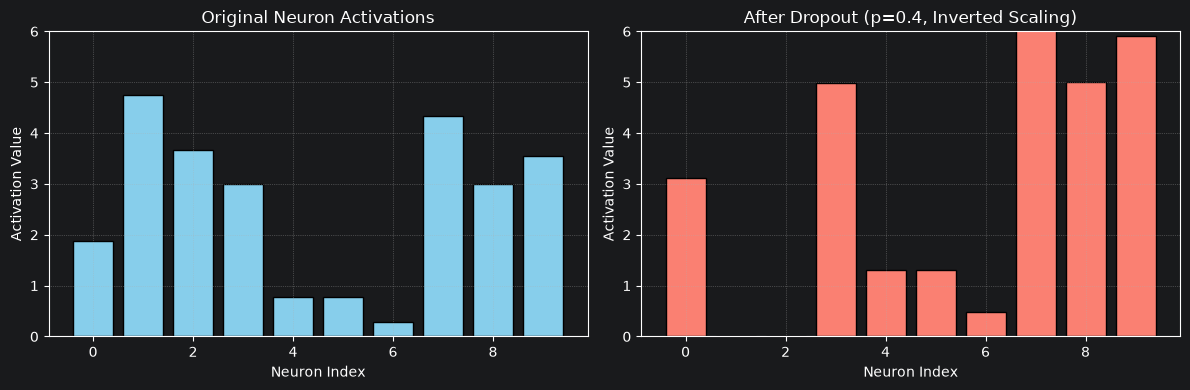

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a layer with 10 neurons
np.random.seed(42)
activations = np.random.rand(10) * 5
dropout_p = 0.4

# Apply dropout mask (keep probability = 1 - dropout_p)
mask = np.random.binomial(1, 1 - dropout_p, size=activations.shape)
dropped_activations = (activations * mask) / (1 - dropout_p) # Inverted dropout scaling

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(10), activations, color='skyblue', edgecolor='black')
axes[0].set_title("Original Neuron Activations")
axes[0].set_ylim(0, 6)

axes[1].bar(range(10), dropped_activations, color='salmon', edgecolor='black')
axes[1].set_title(f"After Dropout (p={dropout_p}, Inverted Scaling)")
axes[1].set_ylim(0, 6)

for ax in axes:
    ax.set_xlabel("Neuron Index")
    ax.set_ylabel("Activation Value")
    ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Batch Normalization
* Definition: Normalizes layer activations across the current mini-batch to have zero mean and unit variance, followed by learnable scale and shift parameters.
* Use Cases: Deep feedforward and convolutional neural networks (CNNs).
* Pros:
    * Accelerates training speed and allows higher learning rates.
    * Reduces sensitivity to initial weight choices and acts as a mild regularizer.
* Cons:
    * Performs poorly with very small batch sizes.
    * Increases architectural complexity and behaves differently during training vs. inference.

### Visualizing Batch Normalization
Batch normalization takes unnormalized activations with arbitrary mean and variance and centers them to zero mean and unit variance per batch.

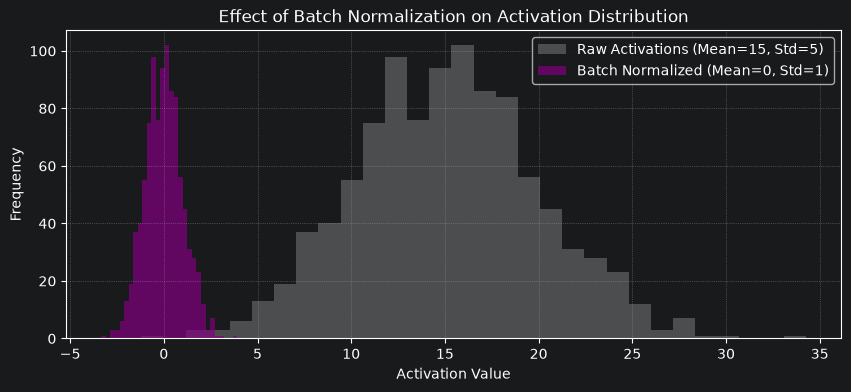

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
# Raw activations with high mean and variance (e.g., mean=15, std=5)
raw_activations = np.random.randn(1000) * 5 + 15

# Batch Normalization (Zero mean, unit variance)
normalized_activations = (raw_activations - np.mean(raw_activations)) / np.std(raw_activations)

plt.figure(figsize=(10, 4))
plt.hist(raw_activations, bins=30, alpha=0.5, label="Raw Activations (Mean=15, Std=5)", color="gray")
plt.hist(normalized_activations, bins=30, alpha=0.7, label="Batch Normalized (Mean=0, Std=1)", color="purple")

plt.xlabel("Activation Value")
plt.ylabel("Frequency")
plt.title("Effect of Batch Normalization on Activation Distribution")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

## 6. Layer Normalization
* Definition: A technique that normalizes inputs across the features of each individual sample independently rather than across the batch dimension.
* Use Cases: Recurrent Neural Networks (RNNs) and Transformers.
* Pros:
    * Completely independent of batch size, making it ideal for sequence modeling and dynamic batch environments.
    * Provides stable training for attention mechanisms.
* Cons:
    * Less effective than batch normalization in standard spatial computer vision tasks (CNNs).
    * Introduces minor computational overhead per layer.

### Visualizing Normalization Axes (Batch Norm vs. Layer Norm)
This diagrammatic scatter plot illustrates how Batch Normalization normalizes *across batches* per feature, whereas Layer Normalization normalizes *across features* per sample.

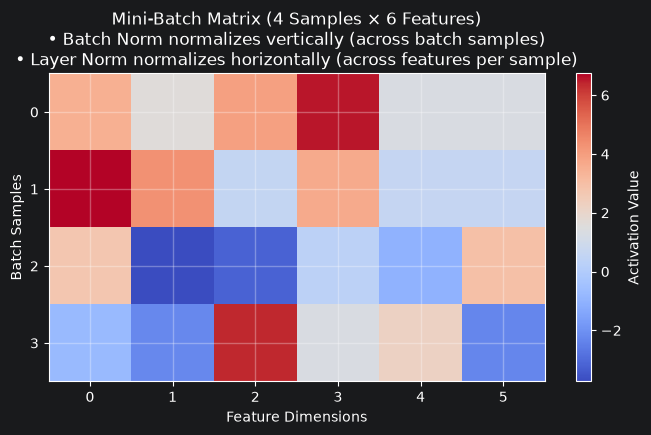

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a mini-batch of samples (rows) and features (columns)
batch_size, num_features = 4, 6
np.random.seed(42)
data_matrix = np.random.randn(batch_size, num_features) * 3 + 2

plt.figure(figsize=(8, 4))
plt.imshow(data_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Activation Value')
plt.title(f"Mini-Batch Matrix ({batch_size} Samples × {num_features} Features)\n• Batch Norm normalizes vertically (across batch samples)\n• Layer Norm normalizes horizontally (across features per sample)")
plt.xlabel("Feature Dimensions")
plt.ylabel("Batch Samples")
plt.xticks(range(num_features))
plt.yticks(range(batch_size))
plt.grid(color='white', linestyle='-', linewidth=1, alpha=0.3)
plt.show()

## 7. Label Smoothing
* Definition: A regularization technique that softens hard target labels (e.g., changing 1.0 to $0.9$ and 0.0 to small values) to prevent the model from becoming overly confident.
* Use Cases: Multi-class classification tasks with deep neural networks (e.g., image recognition, transformer output layers).
* Pros:
    * Discourages extreme logit outputs and improves model calibration.
    * Prevents overfitting on noisy or mislabeled training data.
* Cons:
    * Can slightly decrease training accuracy.
    * Introduces an extra hyperparameter (smoothing factor $\alpha$) that must be tuned.

### Visualizing Label Smoothing
Comparison between a Hard Target (one-hot encoded) and a Softened Target distribution used in Label Smoothing.

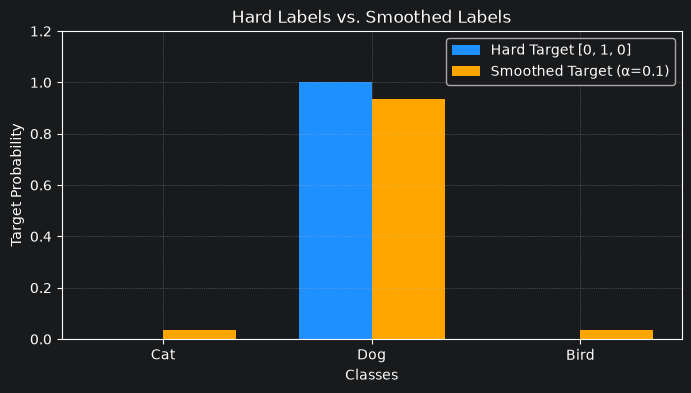

In [11]:
import numpy as np
import matplotlib.pyplot as plt

classes = ['Cat', 'Dog', 'Bird']
hard_label = [0.0, 1.0, 0.0]  # True class is Dog (index 1)
smoothing = 0.1
num_classes = len(classes)

# Label smoothing formula: (1 - alpha)*y + alpha / K
soft_label = [(1 - smoothing) * y + smoothing / num_classes for y in hard_label]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, hard_label, width, label='Hard Target [0, 1, 0]', color='dodgerblue')
plt.bar(x + width/2, soft_label, width, label=f'Smoothed Target (α={smoothing})', color='orange')

plt.xlabel("Classes")
plt.ylabel("Target Probability")
plt.title("Hard Labels vs. Smoothed Labels")
plt.xticks(x, classes)
plt.legend()
plt.ylim(0, 1.2)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

## 8. Early Stopping
* Definition: A regularization strategy that monitors validation loss during training and halts the process when performance stops improving.
* Use Cases: Any iterative training loop in machine learning or deep learning.
* Pros:
    * Simple to implement and saves computation time.
    * Prevents the model from entering the overfitting phase, preserving peak generalization performance.
* Cons:
    * Requires setting a patience parameter; stopping too early causes underfitting, while stopping too late allows mild overfitting.

### Visualizing Early Stopping and Patience Threshold
Monitoring validation loss to intercept the model before overfitting worsens.

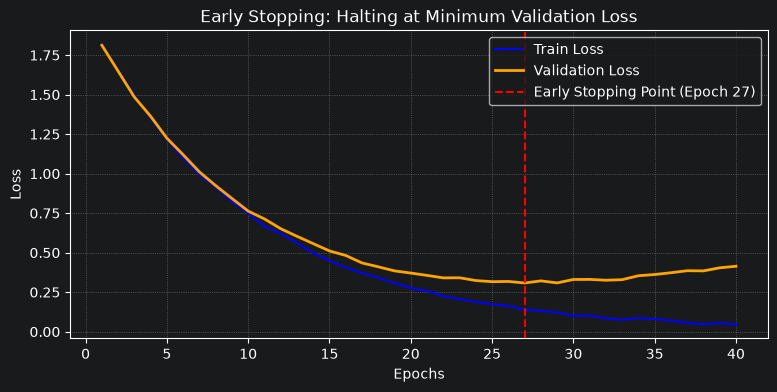

In [12]:
import numpy as np
import matplotlib.pyplot as plt

epochs = 40
np.random.seed(42)
train_loss = [2.0 * np.exp(-e / 10.0) + 0.02 * np.random.rand() for e in range(1, epochs + 1)]
val_loss = [2.0 * np.exp(-e / 10.0) + 0.015 * (e / 8.0)**2 + 0.02 * np.random.rand() for e in range(1, epochs + 1)]

optimal_epoch = np.argmin(val_loss) + 1

plt.figure(figsize=(9, 4))
plt.plot(range(1, epochs + 1), train_loss, label="Train Loss", color="blue")
plt.plot(range(1, epochs + 1), val_loss, label="Validation Loss", color="orange", linewidth=2)
plt.axvline(x=optimal_epoch, color="red", linestyle="--", label=f"Early Stopping Point (Epoch {optimal_epoch})")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Early Stopping: Halting at Minimum Validation Loss")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()